# Introduction

The objective of this notebook is to apply Principal Component Analysis (PCA) to reduce the dimensionality of an employee dataset and identify the most important attributes for predicting employee turnover.

Throughout this exercise, the following tasks will be addressed:

1. Data Preparation: Load and preprocess the employee data, handling missing values and encoding categorical variables.

2. Dimensionality Reduction with PCA: Apply PCA to reduce the feature space and identify the principal components that capture the most variance.

3. Feature Importance Analysis: Determine which original attributes contribute most to the principal components, revealing key drivers of employee turnover.

This exercise provides hands-on experience with dimensionality reduction, feature selection, and building predictive models for employee retention.

# 1. Import libraries

In [1]:
import pandas as pd

# Library for standardizing data
from sklearn.preprocessing import StandardScaler

#Library for performing PCA

from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import random
get_colors = lambda n: list(map(lambda i: "#" + "%06x" % random.randint(0, 0xFFFFFF),range(n)))

# 2. Load data

In [77]:
data_empleados=pd.read_excel('empleadosTecnologiaAlpesMod3y4.xlsx', sheet_name='empleadosTecnologíaAlpes')
pd.set_option('display.max_columns', None)
data_empleados.head(5)

,Edad,Retirado,TarifaSalarial,ID Departamento,DistanciaDesdeCasa,Educacion,CampoEducacion,EmpleadosACargo,NumeroEmpleado,NivelSatisfaccion,Genero,SalarioPorHora,NivelInvolucramiento,NivelResponsabilidad,Rol ID,SatisfaccionTrabajo,EstadoCivil,SalarioMensual,TarifaMensual,NumEmpresasDondeTrabaja,MasDe18Horas,HorasExtra,PorcentajeIncrementoSalarioUltimoAnnio,NivelRendimiento,SatisfaccionEmpresa,HorasEstandar,PlanSalarioComplementario,TotalAnniosTrabajados,FormacionUltimoAnnio,BalanceTrabajoVida,FechaIngresoEmpresa,AnniosEnEmpresa,AnniosRolActual,AnniosDesdeUltimaPromocion,AnniosActualDirector
0,41,Si,1102,3,1,2,Ciencias de la vida,1.0,1,2,Femenino,94,3,2,5,4,Soltero,5993,19479,8,S,Si,11,3,1,80,0,8,0,1,2015-07-26,6,4,0,5
1,49,No,279,1,8,1,Ciencias de la vida,1.0,2,3,Masculino,61,2,2,1,2,Casado,5130,24907,1,S,No,23,4,4,80,1,10,3,3,2011-02-15,10,7,1,7
2,37,Si,1373,1,2,2,Otro,1.0,4,4,Masculino,92,2,1,9,3,Soltero,2090,2396,6,S,Si,15,3,2,80,0,7,3,3,2021-06-02,0,0,0,0
3,33,No,1392,1,3,4,Ciencias de la vida,1.0,5,4,Femenino,56,3,1,1,3,Casado,2909,23159,1,S,Si,11,3,3,80,0,8,3,3,2013-09-26,8,7,3,0
4,27,No,591,1,2,1,Medicina,1.0,7,1,Masculino,40,3,1,9,2,Casado,3468,16632,9,S,No,12,3,4,80,1,6,3,3,2019-03-02,2,2,2,2


In [78]:
data_empleados.shape

(1492, 35)

In [79]:
data_empleados.dtypes

Edad                                               int64
Retirado                                          object
TarifaSalarial                                     int64
ID Departamento                                    int64
DistanciaDesdeCasa                                 int64
Educacion                                          int64
CampoEducacion                                    object
EmpleadosACargo                                  float64
NumeroEmpleado                                     int64
NivelSatisfaccion                                  int64
Genero                                            object
SalarioPorHora                                     int64
NivelInvolucramiento                               int64
NivelResponsabilidad                               int64
Rol ID                                             int64
SatisfaccionTrabajo                                int64
EstadoCivil                                       object
SalarioMensual                 

# 3. Data preparation

Remove null values and duplicates

In [80]:
data_empleados = data_empleados.drop_duplicates()
data_empleados = data_empleados.dropna()

Apply transformations to text-to-number data

In [81]:
data_empleados['Retirado'] = data_empleados['Retirado'].map({'No': 0, 'Si': 1})

data_empleados['CampoEducacion'] = data_empleados['CampoEducacion'].map({
    'Ciencias de la vida': 1,
    'Medicina': 2,
    'Mercadeo': 3,
    'mercaeo': 3,
    'Nivel tecnico': 4,
    'Otro': 5,
    'Talento Humano': 6
}).astype('Int64')

data_empleados['Genero'] = data_empleados['Genero'].map({'Femenino': 0, 'Masculino': 1}).astype('int8')

data_empleados['EstadoCivil'] = data_empleados['EstadoCivil'].map({'Soltero': 1, 'Casado': 2, 'Divorciado': 3}).astype('int8')

data_empleados['HorasExtra'] = data_empleados['HorasExtra'].map({'No': 0, 'Si': 1}).astype('int8')
#The ‘FechaIngresoEmpresa’ variable must be changed to a numeric type
data_empleados['FechaIngresoEmpresa'] = pd.to_datetime(data_empleados['FechaIngresoEmpresa'])
data_empleados['FechaIngresoEmpresa'] = (data_empleados['FechaIngresoEmpresa'] - pd.Timestamp('1970-01-01')).dt.days

In [82]:
data_empleados.isna().sum()[data_empleados.isna().sum() > 0]

CampoEducacion    3
dtype: int64

In [83]:
data_empleados = data_empleados.dropna()

Remove identifiers and variables that are not necessary.
'MasDe18Horas' and 'EmpleadosACargo' have the same value for all rows

In [84]:
data_empleados = data_empleados.drop(columns=['NumeroEmpleado','MasDe18Horas','EmpleadosACargo'])

In [85]:
data_empleados.dtypes

Edad                                      int64
Retirado                                  int64
TarifaSalarial                            int64
ID Departamento                           int64
DistanciaDesdeCasa                        int64
Educacion                                 int64
CampoEducacion                            Int64
NivelSatisfaccion                         int64
Genero                                     int8
SalarioPorHora                            int64
NivelInvolucramiento                      int64
NivelResponsabilidad                      int64
Rol ID                                    int64
SatisfaccionTrabajo                       int64
EstadoCivil                                int8
SalarioMensual                            int64
TarifaMensual                             int64
NumEmpresasDondeTrabaja                   int64
HorasExtra                                 int8
PorcentajeIncrementoSalarioUltimoAnnio    int64
NivelRendimiento                        

# 4. PCA

In [86]:
# Create a data transformer that will standardize the data
standard = StandardScaler()
# Apply the transformation
standard_attribute=standard.fit_transform(data_empleados)
standard_attribute

array([[ 0.45257661,  2.27114941,  0.73780276, ..., -0.05895264,
        -0.67686778,  0.25026928],
       [ 1.32943429, -0.44030569, -1.30364727, ...,  0.77389786,
        -0.3623349 ,  0.81288713],
       [ 0.01414777,  2.27114941,  1.41001778, ..., -1.16941996,
        -0.67686778, -1.15627532],
       ...,
       [-0.31467386, -0.44030569, -0.43795339, ..., -0.33656947,
        -0.3623349 , -0.59365748],
       [-1.52035316,  2.27114941,  1.08755301, ..., -1.16941996,
        -0.67686778, -1.15627532],
       [-1.52035316,  2.27114941,  1.27855137, ..., -0.05895264,
        -0.3623349 , -0.59365748]], shape=(1441, 32))

In [91]:
# ESelect the number of components
n_comp=15

pca = PCA(n_components=n_comp)
# Make the transformation
principal_components = pca.fit_transform(standard_attribute)

component_data = pd.DataFrame(
    principal_components,
    columns=[f'componente principal {i+1}' for i in range(n_comp)]
)

component_data.head()

,componente principal 1,componente principal 2,componente principal 3,componente principal 4,componente principal 5,componente principal 6,componente principal 7,componente principal 8,componente principal 9,componente principal 10,componente principal 11,componente principal 12,componente principal 13,componente principal 14,componente principal 15
0,0.669745,0.807089,-1.353702,-2.006157,1.699024,-2.736798,-0.153654,-1.048874,0.796221,0.347825,1.661818,1.368012,-1.188055,-0.982539,0.880925
1,-1.034818,-0.919807,3.162933,-0.521417,-0.860752,0.043163,-0.993242,-0.684479,-0.995107,-0.601250,-1.120495,-2.163004,1.415332,-0.603369,-0.291887
2,3.249260,0.420816,-0.841106,-1.557181,1.791882,0.123446,-0.022970,1.458052,0.796378,-1.856974,2.235217,-0.218903,-1.013658,-0.616562,0.835778
3,0.484747,-0.273656,-1.081814,0.114981,-1.140809,-1.482436,-1.866342,0.596472,-1.755455,0.054985,0.586203,1.000342,-0.301671,1.032657,0.573658
4,2.210797,0.419086,-0.793889,0.534228,-0.474234,0.547618,0.740478,-0.195458,0.493799,-1.322300,0.275320,-1.572572,1.977015,-0.080651,-0.180014


### Explained variance

In [92]:
pca.explained_variance_ratio_

array([0.17669739, 0.06498643, 0.05769905, 0.05634401, 0.04301025,
       0.03992922, 0.03792167, 0.03586703, 0.03485726, 0.03357635,
       0.03322695, 0.03284022, 0.03230303, 0.03163616, 0.03039276])

In [93]:
sum(pca.explained_variance_ratio_)

np.float64(0.7412877737015472)

15 components represent 74% of the variance

<BarContainer object of 15 artists>

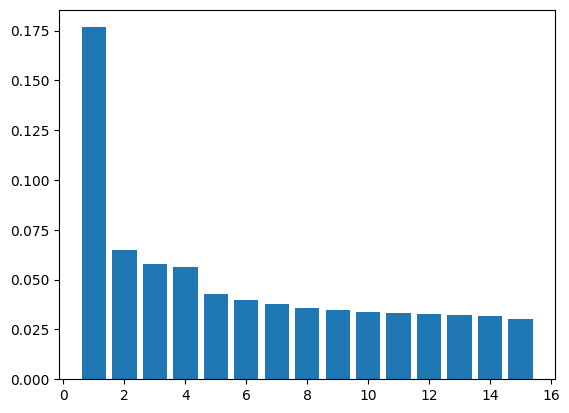

In [96]:
components = list(range(1,n_comp + 1))
variance = list(pca.explained_variance_ratio_)
plt.bar(components,variance)

# Conclusions

Principal component analysis (PCA) shows that the first few components do not account for a high proportion of the total variance. The first component explains approximately 17.67% of the variability, while the first 4 and 5 components account for about 35.57% and 39.87%, respectively.

These results indicate that reducing the dataset to only 4 or 5 components would entail a considerable loss of information. Therefore, the data structure exhibits variability distributed across multiple variables and requires a larger number of components to adequately represent the original information.